W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
✅ 적용된 폰트: NanumGothic

[20년] 월말 로그수익률 상관관계


,SPY(미국주식),HYG(하이일드),HG=F(구리선물),UUP(달러강세),^VIX(VIX지수)
SPY(미국주식),1.000,0.755,0.453,-0.450,-0.724
HYG(하이일드),0.755,1.000,0.403,-0.505,-0.557
HG=F(구리선물),0.453,0.403,1.000,-0.491,-0.281
UUP(달러강세),-0.450,-0.505,-0.491,1.000,0.342
^VIX(VIX지수),-0.724,-0.557,-0.281,0.342,1.000


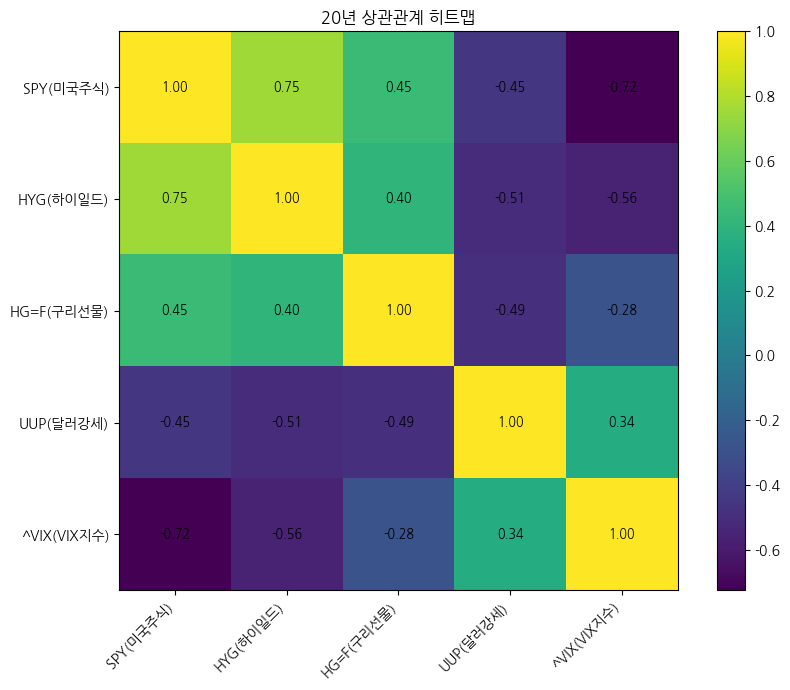


[10년] 월말 로그수익률 상관관계


,SPY(미국주식),HYG(하이일드),HG=F(구리선물),UUP(달러강세),^VIX(VIX지수)
SPY(미국주식),1.000,0.815,0.394,-0.368,-0.748
HYG(하이일드),0.815,1.000,0.370,-0.457,-0.569
HG=F(구리선물),0.394,0.370,1.000,-0.403,-0.330
UUP(달러강세),-0.368,-0.457,-0.403,1.000,0.307
^VIX(VIX지수),-0.748,-0.569,-0.330,0.307,1.000


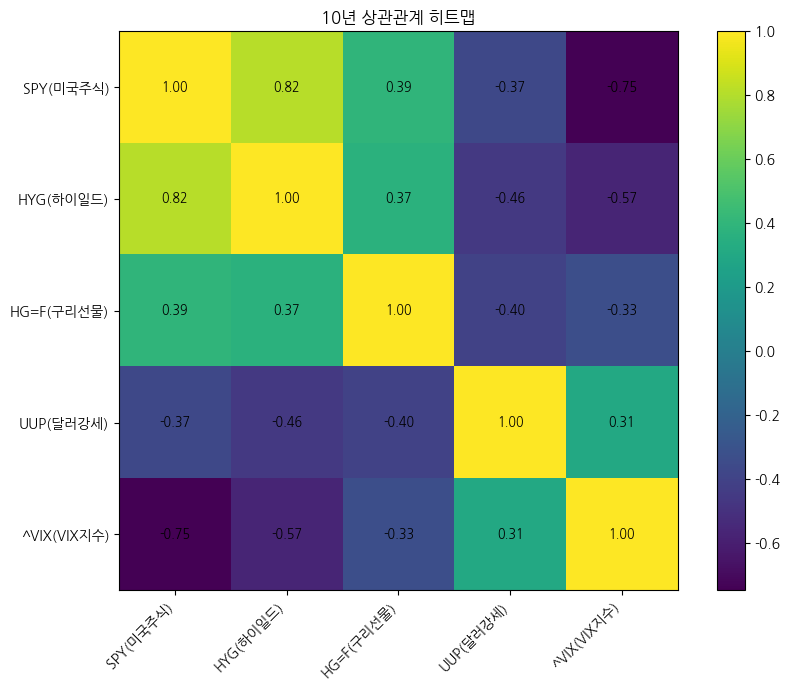


[5년] 월말 로그수익률 상관관계


,SPY(미국주식),HYG(하이일드),HG=F(구리선물),UUP(달러강세),^VIX(VIX지수)
SPY(미국주식),1.000,0.836,0.296,-0.391,-0.731
HYG(하이일드),0.836,1.000,0.299,-0.525,-0.564
HG=F(구리선물),0.296,0.299,1.000,-0.477,-0.219
UUP(달러강세),-0.391,-0.525,-0.477,1.000,0.348
^VIX(VIX지수),-0.731,-0.564,-0.219,0.348,1.000


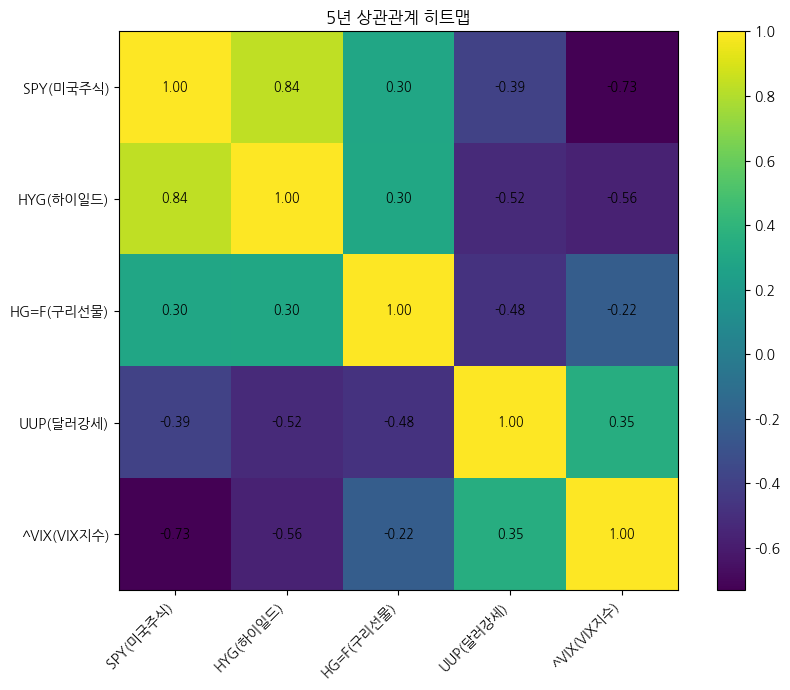


✅ 엑셀 저장 완료 → 한글정상_상관관계_구리선물_VIX.xlsx

📌 카나리아 4개 (실무 최종)
1️⃣ SPY  : 시장 전체 위험
2️⃣ HYG  : 신용 위험
3️⃣ HG=F : 경기 민감도
4️⃣ UUP  : 달러·긴축 스트레스
※ ^VIX는 경보용 신호로 활용


In [16]:
# =========================================================
# [Colab 최종 올인원]
# ✔ 한글 폰트 완전 해결 (NanumGothic 강제 적용)
# ✔ SPY NaN 문제 해결
# ✔ CPER → 구리선물(HG=F)
# ✔ VXX → VIX지수(^VIX)
# ✔ 20년 / 10년 / 5년 상관관계
# =========================================================

# -----------------------------
# 0️⃣ 라이브러리 + 한글 폰트 설치
# -----------------------------
!pip -q install yfinance pandas numpy matplotlib openpyxl koreanize-matplotlib
!apt-get -qq update
!apt-get -qq install -y fonts-nanum

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import koreanize_matplotlib  # ★ 이게 핵심

# -----------------------------
# 1️⃣ 한글 폰트 강제 설정 (Colab 필수)
# -----------------------------
font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()
plt.rcParams["axes.unicode_minus"] = False

print("✅ 적용된 폰트:", font_prop.get_name())

# -----------------------------
# 2️⃣ 기본 설정
# -----------------------------
기준일 = "2025-12-31"
결과파일 = "한글정상_상관관계_구리선물_VIX.xlsx"

티커 = {
    "SPY(미국주식)": "SPY",
    "HYG(하이일드)": "HYG",
    "HG=F(구리선물)": "HG=F",
    "UUP(달러강세)": "UUP",
    "^VIX(VIX지수)": "^VIX",
}

# -----------------------------
# 3️⃣ 데이터 다운로드 (SPY 안정판)
# -----------------------------
def 가격_다운로드(tickers, start, end):
    end_ex = (pd.to_datetime(end) + pd.Timedelta(days=1)).strftime("%Y-%m-%d")
    series = []

    for 이름, 코드 in tickers.items():
        df = yf.download(코드, start=start, end=end_ex, auto_adjust=True, progress=False)

        if df.empty:
            print("❌ 다운로드 실패:", 이름)
            continue

        close_data = df["Close"]
        if isinstance(close_data, pd.DataFrame):
            # If 'Close' results in a DataFrame (e.g., MultiIndex or unexpected format),
            # try to extract the first column as a Series.
            if not close_data.empty:
                s = close_data.iloc[:, 0].rename(이름)
            else:
                print(f"경고: {이름} ({코드})의 'Close' 데이터가 비어있습니다. 이 티커를 건너뜁니다.")
                continue
        else:
            # If 'Close' is already a Series, proceed normally.
            s = close_data.rename(이름)

        series.append(s)

    return pd.concat(series, axis=1).sort_index()

시작일 = (pd.to_datetime(기준일) - pd.DateOffset(years=20) - pd.DateOffset(months=3)).strftime("%Y-%m-%d")

일별가격 = 가격_다운로드(티커, 시작일, 기준일)

# -----------------------------
# 4️⃣ 월말 가격 + 결측 처리
# -----------------------------
월말가격 = 일별가격.resample("M").last()
월말가격 = 월말가격.ffill().dropna(how="all")

# -----------------------------
# 5️⃣ 로그수익률
# -----------------------------
def 로그수익률(df):
    r = np.log(df / df.shift(1))
    r = r.replace([np.inf, -np.inf], np.nan)
    return r.dropna(how="all")

# -----------------------------
# 6️⃣ 상관관계 + 히트맵
# -----------------------------
def 히트맵(corr, 제목):
    plt.figure(figsize=(9, 7))
    plt.imshow(corr, aspect="equal")
    plt.colorbar()

    plt.xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr)), corr.index)

    for i in range(len(corr)):
        for j in range(len(corr)):
            plt.text(j, i, f"{corr.iloc[i, j]:.2f}",
                     ha="center", va="center", fontsize=9)

    plt.title(제목)
    plt.tight_layout()
    plt.show()

# -----------------------------
# 7️⃣ 20년 / 10년 / 5년 분석
# -----------------------------
결과 = {}

for 이름, 년수 in [("20년", 20), ("10년", 10), ("5년", 5)]:
    시작 = pd.to_datetime(기준일) - pd.DateOffset(years=년수)
    px = 월말가격.loc[월말가격.index >= 시작]
    ret = 로그수익률(px)
    corr = ret.corr()

    결과[이름] = corr

    print("\n" + "="*60)
    print(f"[{이름}] 월말 로그수익률 상관관계")
    print("="*60)
    display(corr.round(3))
    히트맵(corr, f"{이름} 상관관계 히트맵")

# -----------------------------
# 8️⃣ 엑셀 저장
# -----------------------------
with pd.ExcelWriter(결과파일, engine="openpyxl") as writer:
    for 이름, corr in 결과.items():
        corr.round(6).to_excel(writer, sheet_name=f"{이름}_상관관계")

print(f"\n✅ 엑셀 저장 완료 → {결과파일}")

# -----------------------------
# 9️⃣ 카나리아 4개 최종 결론
# -----------------------------
print("\n📌 카나리아 4개 (실무 최종)")
print("1️⃣ SPY  : 시장 전체 위험")
print("2️⃣ HYG  : 신용 위험")
print("3️⃣ HG=F : 경기 민감도")
print("4️⃣ UUP  : 달러·긴축 스트레스")
print("※ ^VIX는 경보용 신호로 활용")

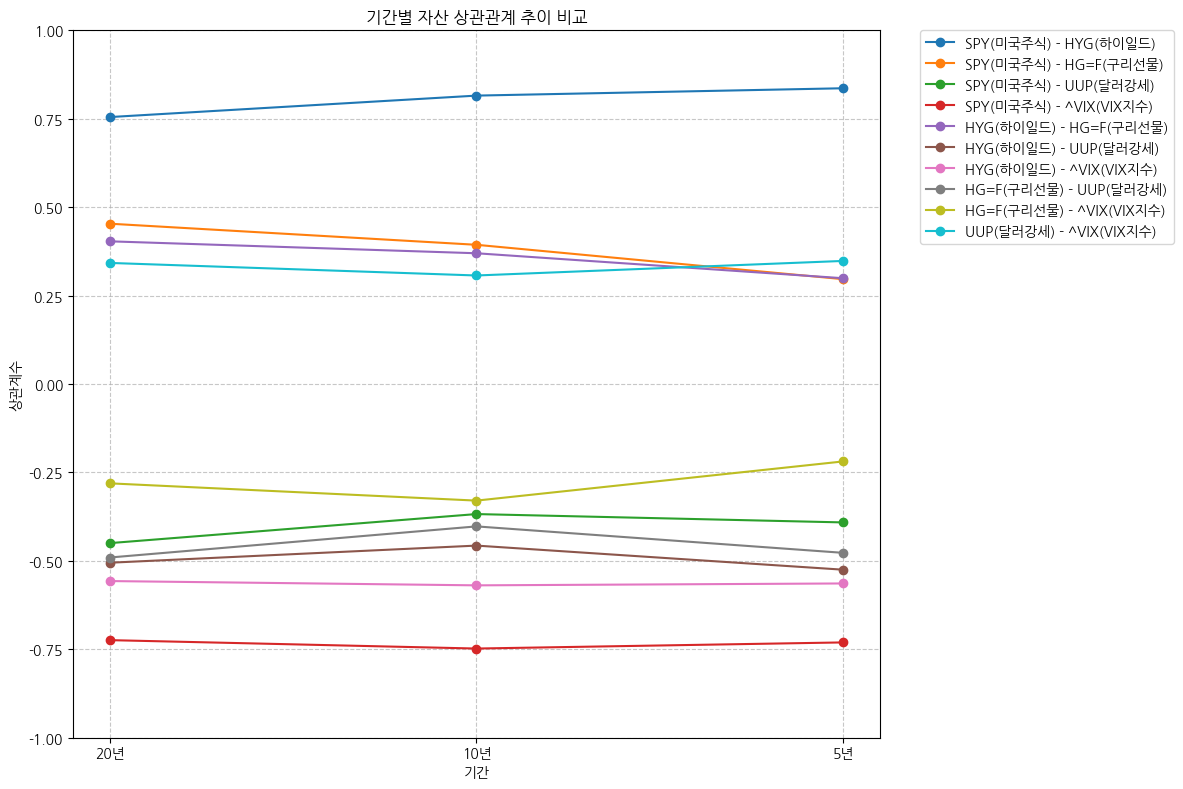

,20년,10년,5년
SPY(미국주식) - HYG(하이일드),0.755,0.815,0.836
SPY(미국주식) - HG=F(구리선물),0.453,0.394,0.296
SPY(미국주식) - UUP(달러강세),-0.450,-0.368,-0.391
SPY(미국주식) - ^VIX(VIX지수),-0.724,-0.748,-0.731
HYG(하이일드) - HG=F(구리선물),0.403,0.370,0.299
HYG(하이일드) - UUP(달러강세),-0.505,-0.457,-0.525
HYG(하이일드) - ^VIX(VIX지수),-0.557,-0.569,-0.564
HG=F(구리선물) - UUP(달러강세),-0.491,-0.403,-0.477
HG=F(구리선물) - ^VIX(VIX지수),-0.281,-0.330,-0.219
UUP(달러강세) - ^VIX(VIX지수),0.342,0.307,0.348


In [18]:
periods = ['20년', '10년', '5년']
asset_names = 결과['20년'].columns

# 각 자산 쌍의 상관관계 추이를 저장할 DataFrame 생성
correlation_trends = pd.DataFrame(index=[], columns=periods)

# 모든 고유한 자산 쌍에 대해 상관관계 추이 추출
for i in range(len(asset_names)):
    for j in range(i + 1, len(asset_names)):
        asset1 = asset_names[i]
        asset2 = asset_names[j]
        pair_name = f"{asset1} - {asset2}"

        trends = []
        for p in periods:
            corr_matrix = 결과[p]
            # NaN 값이 있을 경우 처리 (예: 0으로 대체하거나 스킵)
            if asset1 in corr_matrix.index and asset2 in corr_matrix.columns:
                corr_val = corr_matrix.loc[asset1, asset2]
                trends.append(corr_val)
            else:
                trends.append(np.nan) # 데이터가 없는 경우 NaN 처리

        correlation_trends.loc[pair_name] = trends

# 시각화
plt.figure(figsize=(12, 8))
for pair in correlation_trends.index:
    plt.plot(periods, correlation_trends.loc[pair], marker='o', label=pair)

plt.title('기간별 자산 상관관계 추이 비교')
plt.xlabel('기간')
plt.ylabel('상관계수')
plt.ylim(-1, 1) # 상관계수 범위
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

display(correlation_trends.round(3))